# Chapter 1. Basics and Core Workflow of Qiskit

## 1. Introduction

This chapter follows the official courses in the IBM Quantum Learning Platform, with modifications to be fitted to the live hands-on session:
- [Use a quantum computer today](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today)
- [Build and run your first quantum program](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/build-and-run-your-first-quantum-program)
- [Your first quantum experiment](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/your-first-quantum-experiment)

In this chapter, we will write and run a simple quantum program, and browse the quantum programming workflow with an example simulation problem.

You can run this notebook from top to bottom in a fresh Google Colab runtime, or run locally.

### 1.1. Set up

To run this notebook in Google Colab, you'll need a **Google account** so you can open notebooks and execute cells in the browser.

To run on a real IBM quantum computer, you'll also need a (free) [**IBM Quantum® Platform account**](https://quantum.cloud.ibm.com/signin?redirectTo=%2F).
You can open an instance using the Open Plan to get 10 minutes of quantum processor unit (QPU) time per 28-day rolling window, which actually is quite a lot!
*If you have trouble with your account, see the [Support page](https://quantum.cloud.ibm.com/docs/en/guides/support).*

You can also run this notebook locally after installing Qiskit by following the instructions on [**IBM Quantum Platform**](https://quantum.cloud.ibm.com/docs/en/guides/install-qiskit).

#### Installation and imports

In Colab, we install dependencies inside the notebook so everyone runs the same tools.
The next cell installs Qiskit with the [visualization module](https://quantum.cloud.ibm.com/docs/en/api/qiskit/visualization) plus two add-ons: **Aer** (fast simulators) and the **IBM Runtime** client (for quantum computer runs).

Next, we import the main tools used in this tutorial:

- `QuantumCircuit`: defines qubits and quantum operations.
- `plot_histogram`: visualizes measurement results.
- `AerSimulator`: simulates quantum circuits on a classical computer.
- `preset_passmanagers`: optimizes circuits for quantum hardware.
- `Sampler` and `QiskitRuntimeService`: run circuits on real quantum computers through Qiskit Runtime.


In [1]:
COLAB = False

if COLAB:
    # Colab setup
    from pathlib import Path
    from urllib.request import urlretrieve
    import sys

    DOWNLOAD_DIR = Path(".")
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

    def _download(url: str, dst: Path) -> None:
        dst.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading {url} -> {dst}')
        urlretrieve(url, dst)

    resolved_download_dir = str(DOWNLOAD_DIR.resolve())
    if resolved_download_dir not in sys.path:
        sys.path.insert(0, resolved_download_dir)

    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/utils.py", Path("utils.py"))
    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/linear_h_chains_jw.json", Path("linear_h_chains_jw.json"))
    _download("https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/requirements.txt", Path("requirements.txt"))

In [2]:
!pip install -r requirements.txt

In [3]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import efficient_su2
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime.fake_provider import FakeTorino

# Others
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

Next we'll do a quick environment check. We confirm versions and confirm imports.

If anything fails here, it's usually a dependency install issue; fixing it now prevents confusing errors later.



In [4]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.10
qiskit: 2.3.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.45.1


#### Save IBM Account

![IQP_login.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/IQP_login.png)
1. Login [IBM Quantum Platform](https://quantum.cloud.ibm.com/).
2. Create and copy API Key.
3. Assign the key to `api_token` variable in the next cell
4. Go to [Compute Resource tap](https://quantum.cloud.ibm.com/computers) and check the available backends.


In [5]:
try:
    service = QiskitRuntimeService()
except Exception:
    api_token = "Your_Token_Here"  # Replace with your actual API token
    QiskitRuntimeService.save_account(
        token=api_token,
        overwrite=True
    )
    service = QiskitRuntimeService()

backend_name = "ibm_boston"

qiskit_runtime_service.__init__:WARNING:2026-05-03 21:39:28,378: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (premium, internal), the available account instances are: Solutions Demo internal fleet, Educational premium fleet, Educational internal fleet, Solutions Notebooks internal fleet, Solutions Notebooks premium fleet, Solutions Demo premium fleet, Solutions Demo internal fleet, Solutions Notebooks premium fleet, Educational premium fleet, Solutions Notebooks internal fleet, Solutions Demo premium fleet, Educational internal fleet. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().



--------

## 2. Create and run a quantum program using Qiskit

### 2.1. Build a Simple Quantum Circuit


<div class="alert alert-block alert-info">
For those who are not familiar with the concept of qubits and quantum circuits, visit
<a>https://quantum.cloud.ibm.com/composer</a>
and browse the guided tutorial from the menu:
<b>Help → Build your first circuit</b>.
</div>

We're going to generate the entangled state called the **$\Phi^+$ (phi-plus) Bell state**:

$$
|\Phi^+\rangle = \frac{1}{\sqrt 2}{|00\rangle + |11\rangle}.
$$

To build the Bell state circuit, we use an $H$ (Hadamard) gate to put the first qubit into an equal superposition.
Then we apply a $CX$ (controlled-NOT) gate, which entangles the two states together.

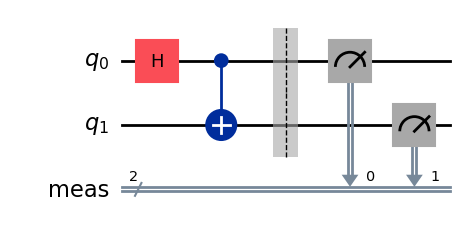

In [6]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

display(bell.draw("mpl"))

#### Helper function for running circuits

Now let's define a helper function that handles the process of running a quantum circuit and retrieving measurement results. This function takes care of transpiling the circuit to match the backend's instruction set, running it through a `Sampler` primitive, and extracting the counts from the results.



In [7]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

### 2.2. Run on a QPU and visualize results

Finally, we run the circuit on an IBM quantum processing unit (QPU) in the cloud for 1000 shots and plot the results. IBM QPUs are physical systems that can pick up noise, so gates are slightly imperfect, measurements can be wrong sometimes, and device calibration drifts over time.

Running on real quantum computers also introduces practical considerations. Jobs can sit in a queue, because many people may be using the same device. You also have to choose a shot count that balances statistical considerations (more shots equals a higher signal-to-noise ratio) with time/cost constraints.

Follow the instructions in the code comments of the next cell. After running the cell, you should see a histogram with approximately equal counts for the $00$ and $11$ bitstrings, with some occurrences of $01$ or $10$ due to noise. The following cell in this notebook runs the same circuit on a simulator, should you choose to skip running on a QPU.



In [8]:
# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend(backend_name)
backend = FakeTorino()

print(backend.name)

fake_torino


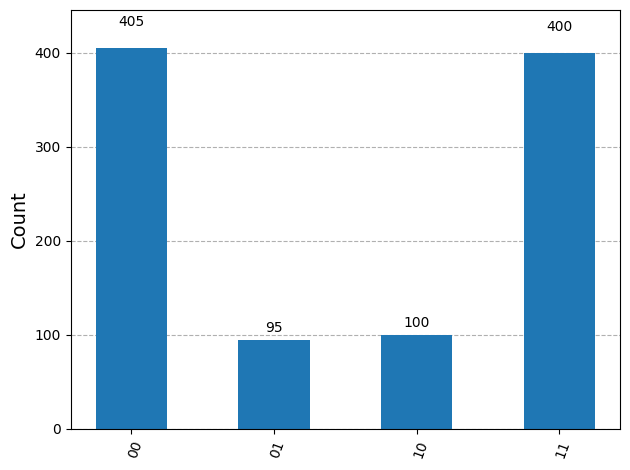

In [9]:
counts_real_backend = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts_real_backend)

### 2.3. Run on a simulator and visualize results

A simulator is a "perfect world" version of quantum computing. Here we run the circuit on a simulator for 1000 shots and plot the results. You should see approximately equal counts for the $00$ and $11$ states, with no occurrences of $01$ or $10$, which is the signature of the Bell state's perfect correlation.



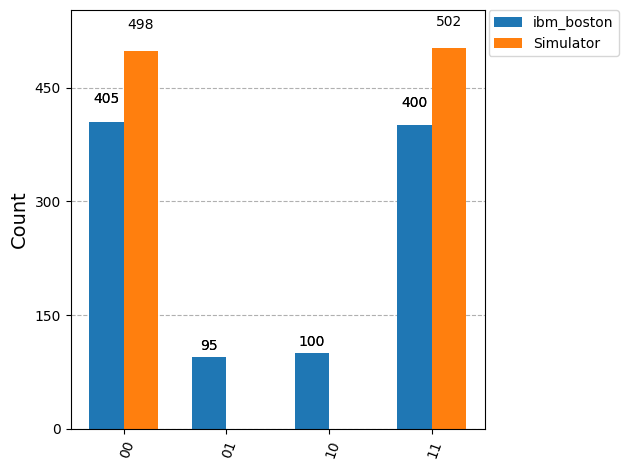

In [10]:
simulator_backend = AerSimulator()
counts_simulator = run_circuit_and_get_counts(bell, simulator_backend, shots=1000)

plot_histogram([counts_real_backend, counts_simulator], legend=[backend_name, "Simulator"])

#### Check your understanding

<div class="alert alert-block alert-success">
<b> Exercise 1. </b> Answer to the following questions.
</div>

Q1. What are the two gates that create the Bell state here?

<details><summary><strong>Answer</strong></summary>
    An H gate on qubit 0, followed by a CX gate with qubit 0 as control and qubit 1 as target.
</details>

Q2. On an ideal simulator, which two bitstrings should dominate the histogram?

<details><summary><strong>Answer</strong></summary>
    00 and 11 should dominate.
</details>

Q3. Why wouldn't a perfect simulator always have the exact same number of 00 counts as 11 counts?

<details><summary><strong>Answer</strong></summary>
    Even though a simulator is "perfect" and leads to a perfect Bell state, it is still simulating an inherently random process, so statistical fluctuations will still occur. It's like flipping a coin 1000 times: even if there is an exact 50-50 chance of the coin landing on heads or tails, that doesn't mean you'll always get exactly 500 instances of heads and 500 of tails.
</details>

Q3. Why might a real quantum computer show some 01 or 10 results even though the simulator didn't?

<details><summary><strong>Answer</strong></summary>
    Because real devices have noise. Gates and measurements are not perfect, and that can introduce occasional errors.
</details>

Q4. What is one practical difference between simulators and real quantum computers besides noise?

<details><summary><strong>Answer</strong></summary>
    Quantum computers can involve queue time, limited availability, and device-specific constraints that affect how circuits run.
</details>



<div class="alert alert-block alert-success">
<b> Exercise 2. </b> Write a code that prepares 3-qubit GHZ state and samples with the backend and simulator.
</div>

$$
|\Psi_{\rm GHZ}\rangle = \frac{1}{\sqrt 2}{|000\rangle + |111\rangle}
$$

Suggested steps:

1. create a 3-qubit circuit,
2. apply `H` to qubit 0,
3. apply two `CX` gates to spread the entanglement (`cx(0, 1)` and `cx(1, 2)`).
4. measure all qubits,
5. run the circuit with `run_circuit_and_get_counts` helper function.
6. show the histogram plot usint `plot_histogram`.


In [11]:
# Your Code Here

<details><summary><strong>Answer</strong></summary>
<pre><code class="language-python">

qc_ghz = QuantumCircuit(3)
qc_ghz.h(0)
qc_ghz.cx(0,1)
qc_ghz.cx(1,2)
qc_ghz.measure_all()
display(qc_ghz.draw("mpl"))

counts_simulator_ghz = run_circuit_and_get_counts(bell, simulator_backend, shots=1000)
counts_backend_ghz = run_circuit_and_get_counts(bell, backend, shots=1000)

display(plot_histogram([counts_real_backend, counts_simulator], legend=[backend_name, "Simulator"]))

</code></pre>


------

## 3. Quantum Experiments with Qiskit and Qiskit Patterns

#### Quantum Simulation of Spin Systems


Now, we'll focus on a problem in the domain of **nature simulation**: using a quantum computer as a controllable stand-in for a natural quantum system.

Specifically, we will simulate the interaction between two spins, which you can think of as **tiny magnets**.
Depending on the sign of their interaction, they might prefer to
- *align* and point in the same direction, or
- *anti-align* and point in opposite directions.

Once we understand this small two-qubit system, we'll show how the same ideas scale up, allowing quantum computers to take advantage of their exponential scaling when simulating large spin systems.


#### Two Interacting Magnets

For this example, we use **two qubits** to represent **two interacting spins**.

The system is described by the Hamiltonian

$$
H = J Z_1 Z_0 + h_x (X_1 + X_0).
$$

<details>
<summary><strong>More details about the system</strong></summary>

Each spin is represented by one qubit:

- $|0\rangle = |\uparrow\rangle$: spin up
- $|1\rangle = |\downarrow\rangle$: spin down

The term $J Z_1 Z_0$ describes the interaction between the two spins.

- If the spins prefer to point in opposite directions, the interaction is called **antiferromagnetic**.
- In that case, the system favors states like $|\uparrow\downarrow\rangle$ and $|\downarrow\uparrow\rangle$.

The terms $h_x X_0$ and $h_x X_1$ describe a **transverse magnetic field**.

- The field can flip each spin.
- Because of this, the relevant quantum states can be superpositions of different spin configurations.

</details>

In physics, the state with the lowest possible energy is called the **ground state**. 
Finding the ground state is an important problem, but here we will do something simpler:
>> Prepare a state and measure the energy.

This type of energy estimation is a basic building block of larger quantum algorithms, such as variational quantum algorithms.

Here, we'll prepare an entangled Bell state, similar to the one we made in the very first lesson of this course:
$$
\vert\Psi\rangle = \frac{1}{\sqrt{2}}(\vert 10\rangle - \vert 01\rangle).
$$



#### Qiskit Pattern

![qiskit_pattern.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/qiskit_pattern.png)

In this section, we will organize the workflow using the **Qiskit pattern**.

| Step | General idea | In our spin problem |
|---|---|---|
| **1. Map** | Express the problem as quantum circuits and operators. | Write the spin Hamiltonian as a qubit operator and prepare a two-qubit state. |
| **2. Optimize** | Convert the circuit into a form suitable for the target backend. | Optimize the circuit so it can run efficiently on the selected backend. |
| **3. Execute** | Run the circuit on a simulator or quantum computer. | Execute the circuit to measure the energy. |
| **4. Postprocess** | Analyze the measurement results to extract the answer. | Simply prints the measured energy. |

This pattern is useful because quantum experiments are not just about writing circuits.
We also need to map the problem, prepare the circuit for hardware, run it, and interpret the results.

Even though this example uses only two qubits, the same pattern is used in larger quantum simulation workflows and other quantum applications.


### 3.1. Map

In general, the mapping step is where we figure out how to represent a real-world problem in terms of qubits, operators, and measurements.
In many applications, this is the trickiest and most involved part of the workflow — even simple questions, like "what does each qubit represent?" do not always have straightforward answers.

In this experiment, however, the mapping is deliberately simple.
Each physical degree of freedom maps directly onto a single qubit.
Because of this one-to-one correspondence, the mapping step reduces to choosing the quantum state we want to prepare and writing a circuit that prepares and measures that state.

First, we define the Hamiltonian as a `SparsePauliOp`.


In [12]:
# Parameters
J = 1.0      # antiferromagnetic coupling
hx = -0.5    # transverse field strength

# or you can parameterize the Hamiltonian.
# J = Parameter("J")
# hx = Parameter("h_x")

# Hamiltonian: H = J Z1 Z0 + hx (X1 + X0)
hamiltonian = SparsePauliOp.from_list([
    ("ZZ", J),
    ("XI", hx),
    ("IX", hx),
])

<div class="alert alert-block alert-info">
    <b>Tip:</b> Instead of assigning numerical Hamiltonian parameters immediately,
    you can keep them symbolic and assign their values later.
</div>
<details>
<summary><strong>Parameterized Hamiltonian</strong></summary>
Define the Hamiltonian with `Parameter` like commented lines, and later assign:
<pre><code class="language-python">
hamiltonian = parameterized_hamiltonian.assign_parameters({
    J: 1.0,
    hx: -0.5,
})
</code></pre>
</details>

Next, we prepare the two-qubit state. Here, we prepare the Bell state

$$
|\Psi^-\rangle = \frac{1}{\sqrt{2}}(|01\rangle - |10\rangle).
$$

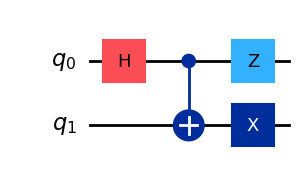

In [13]:
qc = QuantumCircuit(2)

# We also can parameterize the circuit
# theta = Parameter('theta')

qc.h(0)
qc.cx(0, 1)
qc.x(1)
# qc.rx(theta)
qc.z(0)

qc.draw("mpl")

<div class="alert alert-block alert-info">
    <b>Tip:</b> In the same manner with the Hamiltonian, the circuit also can be parameterized.
</div>
<details>
<summary><strong>Parameterized Circuit</strong></summary>
Define the circuit with `Parameter` like commented lines, and later assign:
<pre><code class="language-python">
qc = parameterized_qc.assign_parameters({
    theta: 1.0,
})
</code></pre>
</details>

Notice that we do **not** add measurements here.

With `Estimator`, we give Qiskit the circuit and the observable.
Qiskit handles the required measurements internally.

<details>
<summary><strong>Why no measurement gates?</strong></summary>

When using `Sampler`, we usually add measurement gates and directly sample bitstrings such as `00`, `01`, `10`, and `11`.

When using `Estimator`, our goal is different.  
We want the expectation value of an observable, such as

$$
\langle H \rangle = \langle \psi | H | \psi \rangle.
$$

So instead of manually measuring each qubit, we provide the observable to `Estimator`, and Qiskit determines the required measurement basis.

</details>

### 3.2. Optimize

Before we run our circuit on a quantum computer (or a **fake backend** if you have exhausted your free time on real quantum computers for the month), we need to prepare it for execution.

Specifically, the circuit must be rewritten into a form that respects
- the backend's native gate set,
- connectivity constraints, and 
- optimization opportunities.

This is process such that
> translates the circuit in an **abstract** level to **physical** one.

<div class="alert alert-block alert-info">
<b>Note:</b> This use of the word "optimization" can be confusing. In quantum computing, optimization problems refer to a specific class of problems. Here, we're using optimization to describe a required preparation step that every quantum circuit goes through before it can be run efficiently on hardware.
</div>

During optimization:

1. We choose the backend — either a real quantum computer or a simulator.
2. We assign our circuit's qubits to physical qubits on the device.
3. We rewrite the circuit using only the gates that the quantum computer can actually perform.
4. Optionally implement error mitigation and suppression techniques to reduce the effects of noise.

In Qiskit, this is handled automatically by the transpiler.
Once you pick your backend, the transpiler does all the work to make your circuit ready for execution, so you don't have to manually adjust the gates or qubit assignments.
The transpiler also offers different optimization levels, which can help reduce errors if needed. The optimization is done in stages called 'passes'. So this optimization will be handled by the `pass_manager` in the code below.



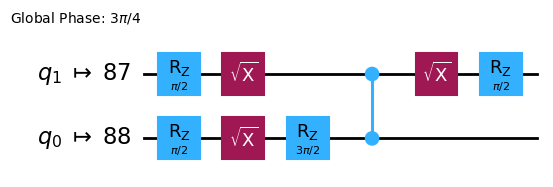

Original Hamiltonian
SparsePauliOp(['ZZ', 'XI', 'IX'],
              coeffs=[ 1. +0.j, -0.5+0.j, -0.5+0.j])
ISA Hamiltonian (133 qubit system)
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
              coeffs=[ 1. +0.j, -0.5+0.j, -0.5+0.j])


In [14]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
)

qc_isa = pm.run(qc)
hamiltonian_isa = hamiltonian.apply_layout(qc_isa.layout)

display(qc_isa.draw("mpl"))
print("Original Hamiltonian")
print(hamiltonian)
print(f"ISA Hamiltonian ({hamiltonian_isa.num_qubits} qubit system)")
print(hamiltonian_isa)

### 3.3. Execute

Now, we are ready to execute. We will load Estimator, then send the circuit plus the list of observables that we want it to estimate to the quantum computer.

In [15]:
estimator = Estimator(mode=backend)

job = estimator.run([(qc_isa, hamiltonian_isa)])
result = job.result()

### 3.4. Postprocess

Finally, we read out the estimated energy.
This part is simple for this example, but may be combined with some classical computation for general tasks.

In [16]:
energy = result[0].data.evs
print(f"Estimated energy: {energy}")

Estimated energy: -0.876708984375


<div class="alert alert-block alert-success">
<b>Exercise 3.</b> Try a different Hamiltonian parameter setting and a different input state.

</div>

In the previous example, we estimated the energy of a Bell state.
Now, change both the Hamiltonian parameters and the state preparation circuit.

- Set the Hamiltonian parameters to $J = 0.7$ and $h_x = -0.3$.
- Prepare the two-qubit state $|++\rangle$.
- Run the same `Estimator` workflow.
- Check the estimated energy.

In [17]:
## Your Code Here
_ = '''  # Remove this line

## Step 1. Map

# Parameters
J = 
hx = 

# Hamiltonian: H = J Z1 Z0 + hx (X1 + X0)
hamiltonian = SparsePauliOp.from_list([
    # Write here
])

# State
qc = QuantumCircuit(2)

# Write here

display(qc.draw("mpl"))

## Step 2. Optimize

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
)

qc_isa = pm.run(qc)
hamiltonian_isa = hamiltonian.apply_layout(qc_isa.layout)

display(qc_isa.draw("mpl"))

## Step 3. Execute

estimator = Estimator(mode=backend)

job = estimator.run([(qc_isa, hamiltonian_isa)])
result = job.result()

## Step 4. Postprocess

energy = result[0].data.evs
print(f"Estimated energy: {energy}")

'''  # Remove this line

# Chapter 2. Variational Quantum Eigensolver (VQE)

This chapter is based on the IBM Quantum Learning course:

[Variational Quantum Eigensolver](https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/vqe)

We will adapt the material for a live hands-on session.

## Goal of this chapter

In the previous chapter, we estimated the energy of a quantum state using `Estimator`.

In this chapter, we go one step further:

> Instead of estimating the energy of one fixed state, we will change the circuit parameters and try to find a lower-energy state.

This is the main idea of the **Variational Quantum Eigensolver**, or **VQE**.

VQE is one of the most important examples of a **hybrid quantum-classical algorithm**:

| Part | Role |
|---|---|
| Quantum computer | Prepares quantum states and estimates their energies. |
| Classical computer | Updates circuit parameters to reduce the energy. |

VQE by itself is not expected to solve all large-scale quantum simulation problems on today’s hardware.  
However, it is still important because it introduces a basic workflow used in many modern quantum algorithms:

1. Prepare a parameterized quantum state.
2. Measure its energy.
3. Use a classical optimizer to improve the parameters.
4. Repeat.

---

## 1. What is VQE?

VQE is an algorithm for approximately finding the **lowest eigenvalue** of an operator.

In physics, this operator is often a **Hamiltonian** $H$, which describes the energy of a system.

The lowest eigenvalue of $H$ is called the **ground-state energy**, and the corresponding eigenstate is called the **ground state**.

The VQE workflow has four main components.

| Component | Meaning | In Qiskit |
|---|---|---|
| **Operator** | The observable we want to minimize, usually a Hamiltonian $H$. | `SparsePauliOp` |
| **Ansatz** | A parameterized quantum circuit that prepares trial states. | `QuantumCircuit` with `Parameter`s |
| **Estimator** | Estimates the expectation value $\langle H \rangle$. | `EstimatorV2` |
| **Classical optimizer** | Updates the circuit parameters to reduce the energy. | `scipy.optimize.minimize` or similar |

The key quantity is the expectation value

$$
E(\boldsymbol{\theta})
=
\langle \psi(\boldsymbol{\theta}) | H | \psi(\boldsymbol{\theta}) \rangle,
$$

where $|\psi(\boldsymbol{\theta})\rangle$ is the quantum state prepared by the parameterized circuit.

The goal of VQE is to find parameters $\boldsymbol{\theta}$ that make this energy as small as possible:

$$
E_\mathrm{VQE}
=
\min_{\boldsymbol{\theta}}
\langle \psi(\boldsymbol{\theta}) | H | \psi(\boldsymbol{\theta}) \rangle.
$$

### 1.1 The VQE loop

<center><img src="https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/vqe.avif" alt="vqe.avif" width="800"/></center>

VQE is a loop between a quantum computer and a classical computer.

1. **Choose initial parameters**: Start with some parameter values $\boldsymbol{\theta}$. 
2. **Prepare state**: Run the ansatz circuit to prepare $|\psi(\boldsymbol{\theta})\rangle$. 
3. **Estimate energy**: Use `Estimator` to compute $\langle H \rangle$. 
4. **Update parameters**: The classical optimizer suggests new parameters. 
5. **Repeat**: Continue until the energy stops improving. 

This is why VQE is called a **hybrid** algorithm.

- The quantum computer evaluates the energy of quantum states.  
- The classical computer decides how to change the parameters.

#### VQE workflow in the Qiskit pattern

The implementation of VQE can be understood through the **Qiskit pattern**, which organizes quantum applications into four stages: **map**, **optimize**, **execute**, and **post-process**.
In IBM Quantum’s terminology, these correspond to: mapping the problem to quantum circuits and operators, optimizing for target hardware, executing on target hardware, and post-processing results.

**map**: prepares the qubit Hamiltonian and choosing a parameterized ansatz circuit.

**optimize**: transpiles that ansatz into an ISA circuit suitable for the selected backend, including layout selection and basis-gate conversion.

**execute**: estimate the energy expectation value for a given parameter set, typically using the `Estimator` primitive, which returns observable expectation values.  

**post-process**: uses those measured energies in a classical optimization loop to update the variational parameters and check convergence.

### 1.2 The operator: Hamiltonian

In physics and chemistry, the word **Hamiltonian** usually means an energy operator.
In quantum computing, the same word is also often used for operators that encode optimization costs.
We are interested in finding the lowest possible energy of the system that the Hamiltonian describes, a task known as the ground-state energy estimation problem.

Mapping a physical or optimization problem to qubits is typically a non-trivial task, but those details are not the focus of this course.

<div class="alert alert-block alert-info">
<b>Tip</b>: A general discussion of mapping a problem to a quantum operator can be found in <a href=https://quantum.cloud.ibm.com/learning/courses/quantum-computing-in-practice>Quantum computing in practice</a>.
</div>

<div class="alert alert-block alert-info">
<b>Tip</b>: A more detailed look at the mapping of chemistry problems into quantum operators can be found in <a href=https://quantum.cloud.ibm.com/learning/en/courses/quantum-chem-with-vqe>Quantum Chemistry with VQE</a>.
</div>


We use the precalculated **4-qubit H₂ Hamiltonian**.
The molecular Hamiltonian is derived from a classical electronic-structure calculation, called Hartree-Fock method with **STO-3G** atomic orbital basis set.
It is then mapped to Pauli operator with [Jordan-Wigner transformation](https://quantum.cloud.ibm.com/learning/en/courses/quantum-computing-in-practice/mapping#jordan-wigner-transformation).

![mol_mapping.jpg](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/mol_mapping.jpg)


In [18]:
hamiltonian = SparsePauliOp([
    'IIII', 'IIIZ', 'IIZI', 'IZII',
    'ZIII', 'IIZZ', 'YXXY', 'XXYY',
    'YYXX', 'XYYX', 'IZIZ', 'ZIIZ',
    'IZZI', 'ZIZI', 'ZZII'
    ],
    coeffs=[
        -0.09886397+0.j,  0.17119775+0.j,  0.17119775+0.j, -0.22278593+0.j,
        -0.22278593+0.j,  0.16862219+0.j,  0.0453222 +0.j, -0.0453222 +0.j,
        -0.0453222 +0.j,  0.0453222 +0.j,  0.12054482+0.j,  0.16586702+0.j,
        0.16586702+0.j,  0.12054482+0.j,  0.17434844+0.j
    ]
)
n_qubits = hamiltonian.num_qubits
n_electrons = 2

#### Exact Diagonalization

The Hamiltonian above is a $16\times 16$ matrix operator. Diagonalizing the operator to find its lowest energy eigenvalue is not difficult.

In [19]:
ham_matrix = hamiltonian.to_matrix()
# with np.printoptions(precision=3, suppress=True, linewidth=200):
#     print("Hamiltonian matrix:\n", H2_matrix.real)
print(f"Hamiltonian matrix shape: {ham_matrix.shape}")

exact_evals, exact_evecs = np.linalg.eigh(ham_matrix)
exact_gnd = float(np.min(exact_evals))
exact_gnd_vec = exact_evecs[:, np.argmin(exact_evals)] # Assume non-degenerated

print(f"Exact ground-state energy: {exact_gnd:.10f}")
print(f"Exact ground-state vector: {Statevector(exact_gnd_vec).draw('latex_source')}".replace(r"\rangle", ">"))
print(f"Number of qubits: {n_qubits}")

Hamiltonian matrix shape: (16, 16)
Exact ground-state energy: -1.1372701657
Exact ground-state vector: -0.9936146064 |0011>+0.1128273636 |1100>
Number of qubits: 4


Brute force classical eigensolvers cannot scale to describe the energies or geometries of very large systems of atoms, like medications or proteins. VQE is one of the early attempts to leverage quantum computing in this problem.

<details> <summary><strong> Hilbert space growth </strong></summary>
Even though this H₂ Hamiltonian is still small enough (16×16) to be diagonalized exactly on a laptop, the matrix size and the classical computational cost grow very quickly as the molecular system becomes larger.
The Hilbert space dimension and the size of the many-body Hamiltonian increase exponentially with the number of considered orbitals, and therefore with the number of qubits.
As an example, a free benzene molecule in the STO-3G basis involves 72 spin orbitals, so the possible Fock basis states scale as 2⁷² ≈ 4.7 x 10²¹!
</details>

We will encounter Hamiltonians in this lesson much larger than that above. But it would be wasteful to push the limits of what VQE can do, before we introduce some of the more advanced tools that can augment or replace VQE, later in this course.

### 1.3 The ansatz: a parameterized quantum circuit

The second ingredient is the **ansatz**: a parameterized quantum circuit used to prepare trial states.
For example, a simple ansatz may contain rotation gates:

$$
R_y(\theta)
$$

where $\theta$ is a tunable parameter.

Different parameter values prepare different quantum states:
$$
|\psi(\theta)\rangle.
$$

The optimizer changes $\theta$ to search for a lower-energy state.

| Ansatz concept | Meaning |
|---|---|
| Circuit structure | Which gates are used |
| Parameters | Values that can be changed |
| Trial state | The quantum state prepared by the circuit |
| Expressibility | How many different states the ansatz can represent |

A good ansatz should be expressive enough to approximate the target state, but not so complicated that it becomes too hard to optimize or run on hardware.

Qiskit supports the following ansatz circuits:

- [`efficient_su2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.efficient_su2): Layers of SU(2) rotations and CX gates, whose connectivity is simplified to make it hardware-efficient.
- [`excitation_preserving`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.excitation_preserving): Preserves number of `1`s in the computational basis state.
- [`evolved_operator_ansatz`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.evolved_operator_ansatz): Usually for quantum-chemistry-inspired ansatz, such as unitary coupled cluster.
- [`n_local`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.n_local): Construct an $n$-local variational circuit.
- [More ansatz circuits](https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit_library#n-local-circuits)

Here, we consider hardware efficient `efficient_su2` ansatz.

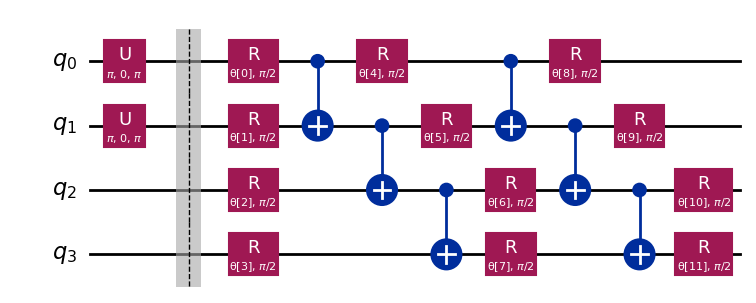

In [20]:
hf_state = QuantumCircuit(n_qubits)

# Initialize to Hartree-Fock state
for i in range(n_electrons):
    hf_state.x(i)
hf_state.barrier()

ansatz = hf_state.compose(
    efficient_su2(
        num_qubits=n_qubits,
        su2_gates=["ry"],
        entanglement="linear",
        reps=2,
        skip_final_rotation_layer=False,
        insert_barriers=False,
    ),
    inplace=False,
)

display(ansatz.decompose().draw("mpl", idle_wires=False))

In [21]:
num_params = ansatz.num_parameters
print("Number of ansatz parameters:", num_params)

Number of ansatz parameters: 12


### 1.4 The Estimator: measuring the energy

The third ingredient is the `Estimator`.

In the previous chapter, we already used `Estimator` to compute

$$
\langle \psi | H | \psi \rangle.
$$

VQE uses the same idea, but repeats it many times for different circuit parameters:

$$
E(\theta)
=
\langle \psi(\theta) | H | \psi(\theta) \rangle.
$$

If we could directly measure the entire operator $H$, this would be as simple as making many (say $N$) measurements and averaging the measured values:

$$
\langle \psi(\vec{\theta})|H|\psi(\vec{\theta})\rangle _N \approx \frac{1}{N}\sum_{j=1}^N {E_j}
$$

Here, the $\approx$ symbol reminds us that this expectation value would only be precisely correct in the limit as $N\rightarrow \infty$. But with thousands of measurements being made on a circuit, the sampling error of the expectation value is fairly low. There are other considerations such as noise that become an issue for very precise calculations.

The following code provides a function that estimates the energy of given ansatz, hamiltonian, parameter and backend.

In [22]:
# Backends
simulator_backend = AerSimulator()  # ideal simulator
fake_backend = FakeTorino()  # simulator imitating the noisy environment of the real backend
# real_backend = service.backend(backend_name)  # real backend

# Estimation of the energy
def estimate_energy(ansatz, ham, theta, backend, param_history, energy_history):
    pub = (ansatz, ham, theta)
    if backend is not None:
        estimator = Estimator(mode=backend)
    else:
        estimator = StatevectorEstimator()
    result = estimator.run([pub]).result()
    energy = float(np.real(result[0].data.evs))
    param_history.append(np.array(theta, dtype=float))
    energy_history.append(energy)
    return energy



### 1.5 The classical optimizer

The fourth ingredient is the **classical optimizer**.

The optimizer does not directly know quantum mechanics.  
It only sees the energy values returned by the quantum computer or simulator.

Its job is simple:

> Try new parameters that make the energy smaller.

Now, we have the final form of vqe, including 

In [23]:
def vqe(ansatz, ham, backend,
        optimization_method="COBYLA",):
    param_history = []
    energy_history = []

    num_params = ansatz.num_parameters

    # Initial parameter values
    initial_theta = np.zeros(num_params)
    parameter_bound = [(-np.pi, np.pi) for _ in range(num_params)]

    def cost_function(theta):
        return estimate_energy(
            ansatz=ansatz,
            ham=ham,
            theta=theta,
            backend=backend,
            param_history=param_history,
            energy_history=energy_history,
        )

    result = minimize(
        cost_function,
        x0=initial_theta,
        method=optimization_method,
        bounds=parameter_bound,
        options={
            "maxiter": 1000,
            "disp": True
        },
    )

    return result, param_history, energy_history

#### Let's run it:

Now, we are all set. Let's run VQE with the ideal simulator.


In [24]:
ideal_res, ideal_theta_list, ideal_energy_list = vqe(ansatz, hamiltonian, backend=None)

ideal_vqe_theta = np.array(ideal_res.x, dtype=float)
ideal_vqe_energy = float(ideal_res.fun)

print(ideal_res.message)
print(f"Final VQE electronic energy: {ideal_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(ideal_vqe_energy-exact_gnd):.3e}")

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 1000   Least value of F = -1.1371875094785935   Constraint violation = 0.0
The corresponding X is:
[ 1.77822141  1.62076304  1.59158318  1.60457919  2.00437045  1.56066928
  1.56827359 -1.51591215  0.04876802 -0.02146615 -0.03523989 -0.05503532]
The constraint value is:
[-4.91981406 -4.76235569 -4.73317583 -4.74617184 -5.1459631  -4.70226194
 -4.70986625 -1.6256805  -3.19036068 -3.1201265  -3.10635277 -3.08655733
 -1.36337125 -1.52082962 -1.55000948 -1.53701346 -1.13722221 -1.58092337
 -1.57331906 -4.65750481 -3.09282463 -3.16305881 -3.17683254 -3.19662798]

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Final VQE electronic energy: -1.1371875095
Exact electronic energy:     -1.1372701657
Absolute error:              8.266e-05


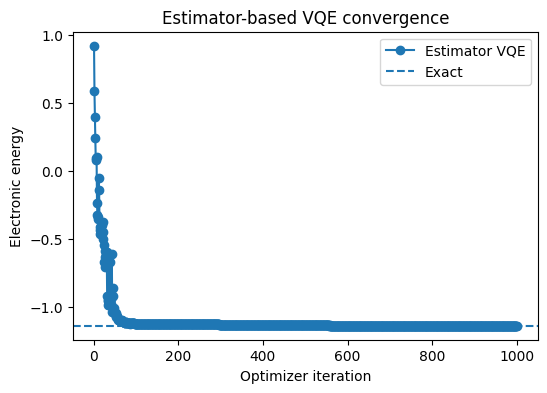

In [25]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(ideal_energy_list)+1), ideal_energy_list, marker="o", label="Estimator VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()


------

## 2. VQE and the Qiskit pattern

Now we switch to the **Qiskit Pattern** view:
- abstract circuit / observable (Already done in Section 1-2 and 1-3),
- transpiled **ISA circuit**,
- layout-applied **ISA observable**,
- execution via `Estimator` or `Sampler`.
  
\*  (ISA = Instruction Set Architecture)

### 2.1. Optimization: Mapping to ISA and Transpilation

The ansatz we constructed above is still an abstract circuit, but real hardware can only run circuits that match its supported basis gates and qubit connectivity. Qiskit therefore uses transpilation to convert the ansatz into an **ISA circuit**, which is the hardware-compatible form required for execution on IBM Quantum backends.

<div class="alert alert-block alert-info">
<b>Tip</b>: Visit <a href=https://quantum.cloud.ibm.com/computers>https://quantum.cloud.ibm.com/computers</a> for available backends.
</div>

In [26]:
print("Selected backend:", backend.name)
print("Backend gate set:", backend.operation_names)
print("Backend coupling map:", backend.coupling_map)
try: # Requires Graphviz to be installed and in PATH
    backend.coupling_map.draw(f"backend_{backend.name}_coupling_map.png")
    print(f"Coupling map diagram saved as backend_{backend.name}_coupling_map.png")
except Exception as e:
    pass

Selected backend: fake_torino
Backend gate set: ['rz', 'cz', 'x', 'reset', 'delay', 'switch_case', 'for_loop', 'measure', 'id', 'if_else', 'sx']
Backend coupling map: [[0, 1], [0, 15], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [4, 3], [4, 5], [4, 16], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [8, 7], [8, 9], [8, 17], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [12, 11], [12, 13], [12, 18], [13, 12], [13, 14], [14, 13], [15, 0], [15, 19], [16, 4], [16, 23], [17, 8], [17, 27], [18, 12], [18, 31], [19, 15], [19, 20], [20, 19], [20, 21], [21, 20], [21, 22], [21, 34], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 35], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 36], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 37], [34, 21], [34, 40], [35, 25], [35, 44], [36, 29], [36, 48], [37, 33], [37, 52], [38, 39], [38, 53], [39, 38], [39, 4

We then generate a preset pass manager with ([`generate_preset_pass_manager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager)), including layout selection, routing, basis-gate translation, and circuit optimization.
This generates a preset [`PassManager`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.PassManager), which manages a set of Passes and their schedule during transpilation.

Here we use `optimization_level=3` to request the heaviest built-in optimization level, and `seed_transpiler=1234` to make the stochastic parts of transpilation reproducible.

In [27]:
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3,
    seed_transpiler=1234,
)
print("Pass manager stages:", pm.stages)
try: # Requires Graphviz to be installed and in PATH
    pm.draw(f"pass_manager_{backend.name}.png")
    print(f"Pass manager diagram saved as pass_manager_{backend.name}.png")
except Exception as e:
    pass

Pass manager stages: ('init', 'layout', 'routing', 'translation', 'optimization', 'scheduling')


After transpilation, the circuit may not use the original logical qubit ordering, because the transpiler can choose a new layout to better match the hardware.  
For that reason, the Hamiltonian must also be updated to the same layout.
Qiskit’s `SparsePauliOp.apply_layout(...)` performs this step, ensuring that the observable is aligned with the transpiled ansatz before expectation values are evaluated. 

Finally, we inspect a few basic properties of the resulting ISA circuit, such as its depth, total size, operation counts, and final qubit layout.  

ISA Hamiltonian:
SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYXXIIIIIIIIIIIIYIIIIIIIIIIIIIIIIII', 'IIIIIIII

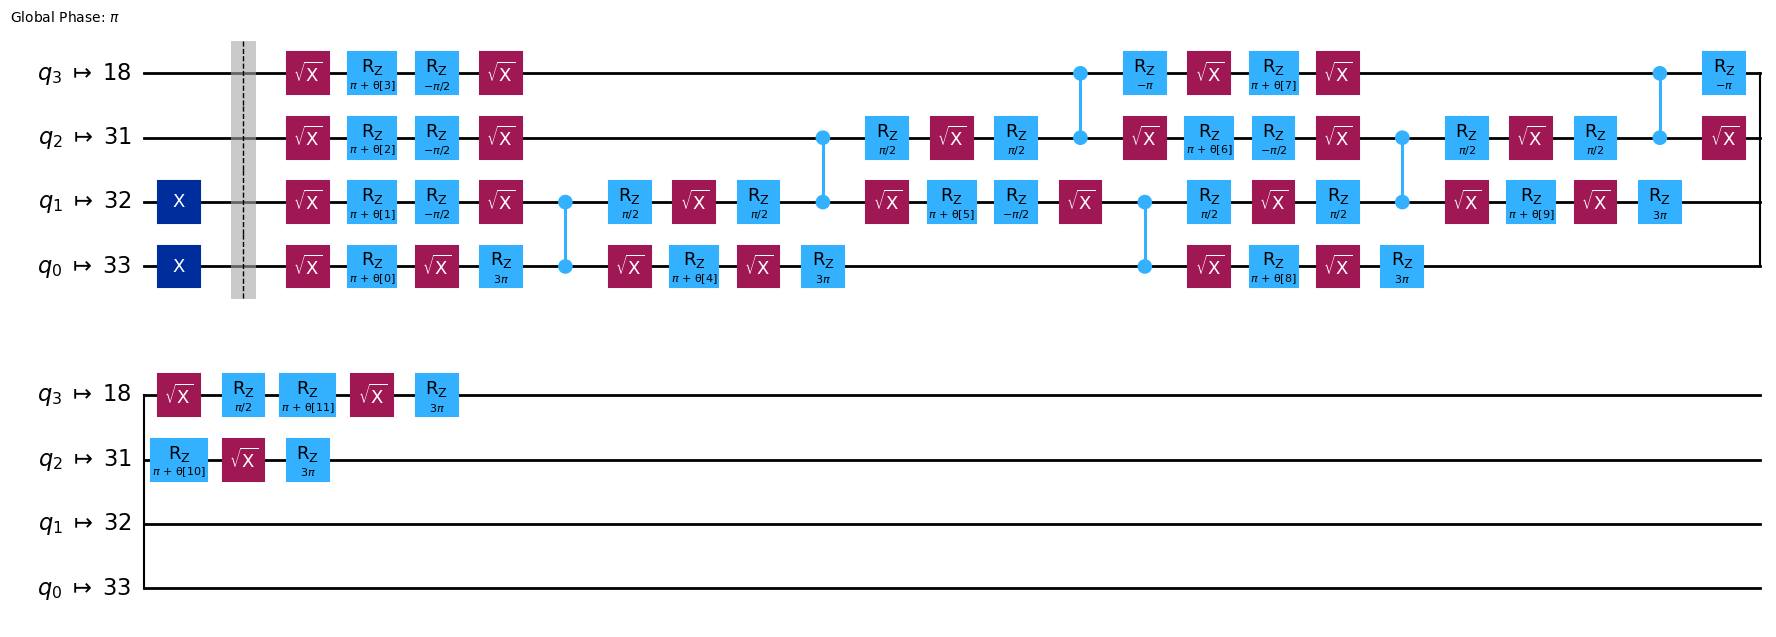

In [28]:
# Transpilation of a circuit to match the target backend's constraints (ISA)
isa_ansatz = pm.run(ansatz) 

# Transform the Hamiltonian to match the qubit layout of the transpiled circuit
isa_hamiltonian = hamiltonian.apply_layout(isa_ansatz.layout)

print("ISA Hamiltonian:")
print(isa_hamiltonian)

print("ISA depth:", isa_ansatz.depth())
print("ISA size:", isa_ansatz.size())
print("ISA operations:", isa_ansatz.count_ops())
print("Layout:", '\n\t'.join(repr(isa_ansatz.layout.initial_layout).splitlines()[:5]), "\n\t...\n\t})")
print("Transpiled Circuit:")
display(isa_ansatz.draw("mpl", idle_wires=False))

### 2.2. Execution and Postprocessing

After building the ansatz and compiling it into an ISA circuit, the next step is to *execute* expectation-value evaluations and turn the raw results into quantities that are useful for chemistry.
In Qiskit's runtime workflow, this usually means sending `(circuit, observable, parameter values)` tuples (i.e. **Primitive Unified Block, PUB**) to an `Estimator`, then postprocessing the returned expectation values to estimate energies, compare different settings, and monitor convergence.

The IBM Runtime execution modes are:

- **Job mode**: *A single run* of a primitive. This is the simplest option, and it is well suited for one-off evaluations such as checking the energy at a specific parameter point.
- **Batch mode**: *Parallel or grouped runs* of primitives. This is useful when several independent workloads should be submitted together, for example when comparing different error-mitigation settings on the same circuit and observable.
- **Session mode**: *Sequential runs* of primitives with reduced latency between calls. This is the most natural mode for hybrid algorithms such as VQE, where each optimizer step requests a new expectation-value evaluation based on the previous result. Session mode is not available for open-access users.

![batch_session.png](https://raw.githubusercontent.com/snow0369/qiskit_handson_260508/main/images/batch_session.png)

In this VQE tutorial, these modes are used for the following purposes:

- **Job mode**: a single-point energy evaluation.
- **Batch mode**: comparison of several [error-mitigation settings](https://quantum.cloud.ibm.com/docs/en/guides/configure-error-mitigation).
- **Session mode**: the actual iterative VQE loop, where parameters are updated repeatedly.

<div class="alert alert-block alert-info">
You can also browse submitted workloads online from 
<a href=https://quantum.cloud.ibm.com/workloads>the IBM Quantum Platform</a>.
</div>

In [29]:
default_shots = 10000

# 1) Job mode: one single energy evaluation
estimator = Estimator(mode=backend, options={"default_shots": default_shots})
pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
job = estimator.run([pub])
print("job status:", job.status())  # Asynchronously check job status in real-time.
result = job.result() # Wait for job to complete and get results
print("job status (after wait):", job.status())
estimated_energy = float(result[0].data.evs[0])
print(f"Single run estimated energy Error: {abs(estimated_energy - exact_gnd):.3f}")

job status: JobStatus.RUNNING
job status (after wait): JobStatus.DONE
Single run estimated energy Error: 0.099


#### Error mitigation on batch mode

In Batch mode, we compare the gradual application of various error mitigation techniques.

`resilience_level = 0`: No mitigation

`resilience_level = 1`: Twirled Readout Error eXtinction (TREX) / measurement mitigation + measurement twirling

`resilience_level = 2`: level 1 + gate twirling + Zero-Noise Extrapolation (ZNE)

In [30]:
# 2) Batch mode: compare several mitigation levels in one grouped submission
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the comparision between different mitigation levels.
'''
with Batch(backend=backend, max_time="5m") as batch:
    pub = (isa_ansatz, isa_hamiltonian, [ideal_vqe_theta])
    # submit separate runs with different option objects or different PUB sets
    batch = [
        Estimator(mode=batch, options={"resilience_level": 0, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 1, "default_shots": default_shots}).run([pub]),
        Estimator(mode=batch, options={"resilience_level": 2, "default_shots": default_shots}).run([pub])
    ]
results = [est.result() for est in batch]
estimated_energies = [float(res[0].data.evs[0]) for res in results]
print(f"Batch run estimated energy Errors: {[abs(energy - exact_gnd) for energy in estimated_energies]}")
'''

''

''

Expected Result:
```
Batch run estimated energy Errors: [0.1417889042648406, 0.06748944597138373, 0.052310730542233896]
```


In [31]:
# 3) Session mode: best for iterative VQE
# This section takes too long time to run, so it is commented out.
# You can uncomment and run it if you want to see the full VQE optimization on a real backend.
'''
energy_history_session = []
param_history_session = []

def estimate_energy_session(theta, ansatz, hamiltonian, session):
    estimator = Estimator(mode=session, options={"resilience_level": 1, "default_shots": default_shots})
    pub = (ansatz, hamiltonian, [theta])
    result = estimator.run([pub]).result()
    evs = float(result[0].data.evs[0])
    energy_history_session.append(evs)
    param_history_session.append(theta)
    return evs

with Session(backend=backend, max_time="10m") as session:
    res = minimize(
        estimate_energy_session,
        ideal_vqe_theta,
        args=(isa_ansatz, isa_hamiltonian, session),
        method="POWELL",
        options={"maxiter": 10, "disp": True},
    )

session_vqe_theta = np.array(res.x, dtype=float)
session_vqe_energy = float(res.fun)

print(res.message)
print(f"Final VQE electronic energy: {session_vqe_energy:.10f}")
print(f"Exact electronic energy:     {exact_gnd:.10f}")
print(f"Absolute error:              {abs(session_vqe_energy-exact_gnd):.3e}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(energy_history_session)+1), energy_history_session, marker="o", label="Real-Backend VQE")
plt.axhline(exact_gnd, linestyle="--", label="Exact")
plt.xlabel("Optimizer iteration")
plt.ylabel("Electronic energy")
plt.title("Estimator-based VQE convergence")
plt.legend()
plt.show()

'''

''

''

<div class="alert alert-box alert-success">
Exercise 5. Estimate the ground state energy of 6-spin system by running VQE algorithm and compare with the exact diagonalization.
</div>

$$
H = \sum_{i=0}^{4}Z_iZ_{i+1} - 0.7\sum_{i=0}^5 X_i
$$

We will:

1. define the Hamiltonian as a `SparsePauliOp`,
2. choose a parameterized ansatz,
3. run VQE using the helper function,
4. compare the VQE result with exact diagonalization.

In [32]:
# Step 1. Map the problem to a Hamiltonian

# Qiskit Pauli strings are ordered as q3 q2 q1 q0.
# Therefore:
# Z0 Z1 -> IIZZ
# Z1 Z2 -> IZZI
# Z2 Z3 -> ZZII

ham_6spin = SparsePauliOp.from_list([
    ("IIIIZZ", 1.0),    # Z0 Z1
    ("IIIZZI", 1.0),    # Z1 Z2
    ("IIZZII", 1.0),    # Z2 Z3
    ("IZZIII", 1.0),    # Z3 Z4
    ("ZZIIII", 1.0),    # Z4 Z5

    ("IIIIIX", -0.7),   # X0
    ("IIIIXI", -0.7),   # X1
    ("IIIXII", -0.7),   # X2
    ("IIXIII", -0.7),   # X3
    ("IXIIII", -0.7),   # X3
    ("XIIIII", -0.7),   # X3
])

print(ham_6spin)


SparsePauliOp(['IIIIZZ', 'IIIZZI', 'IIZZII', 'IZZIII', 'ZZIIII', 'IIIIIX', 'IIIIXI', 'IIIXII', 'IIXIII', 'IXIIII', 'XIIIII'],
              coeffs=[ 1. +0.j,  1. +0.j,  1. +0.j,  1. +0.j,  1. +0.j, -0.7+0.j, -0.7+0.j,
 -0.7+0.j, -0.7+0.j, -0.7+0.j, -0.7+0.j])


Number of parameters: 16


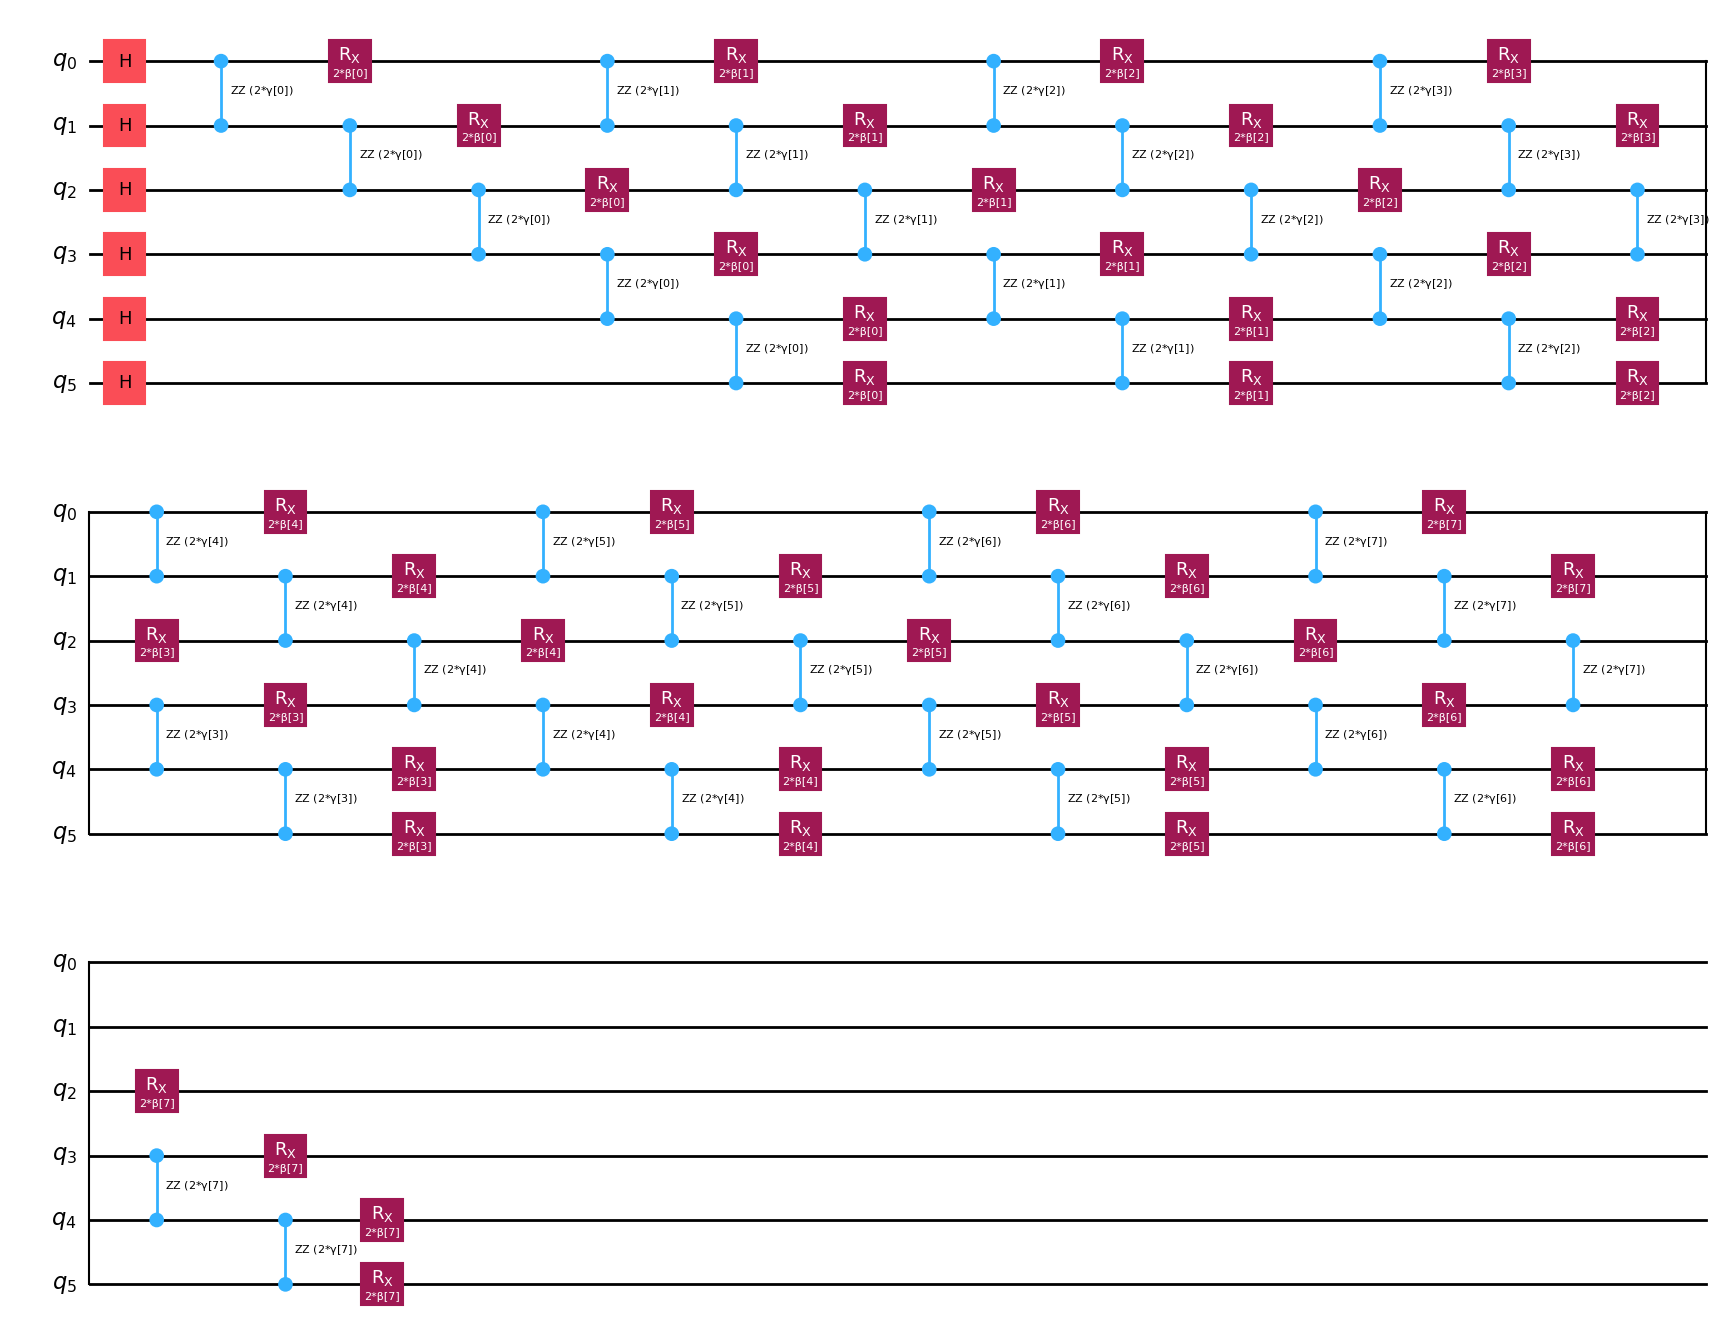

In [34]:
# Step 1. Choose an ansatz

from qiskit.circuit import ParameterVector

def make_tfim_ansatz(num_qubits, reps):
    gamma = ParameterVector("γ", reps)
    beta = ParameterVector("β", reps)

    qc = QuantumCircuit(num_qubits)

    # Start from |+...+>, the ground state of the transverse-field part -sum_i X_i.
    for q in range(num_qubits):
        qc.h(q)

    for layer in range(reps):
        # ZZ interaction layer
        for q in range(num_qubits - 1):
            qc.rzz(2 * gamma[layer], q, q + 1)

        # X-field layer
        for q in range(num_qubits):
            qc.rx(2 * beta[layer], q)

    return qc

ansatz_6spin = make_tfim_ansatz(
    num_qubits=6,
    reps=8,
)

print("Number of parameters:", ansatz_6spin.num_parameters)
display(ansatz_6spin.draw("mpl"))

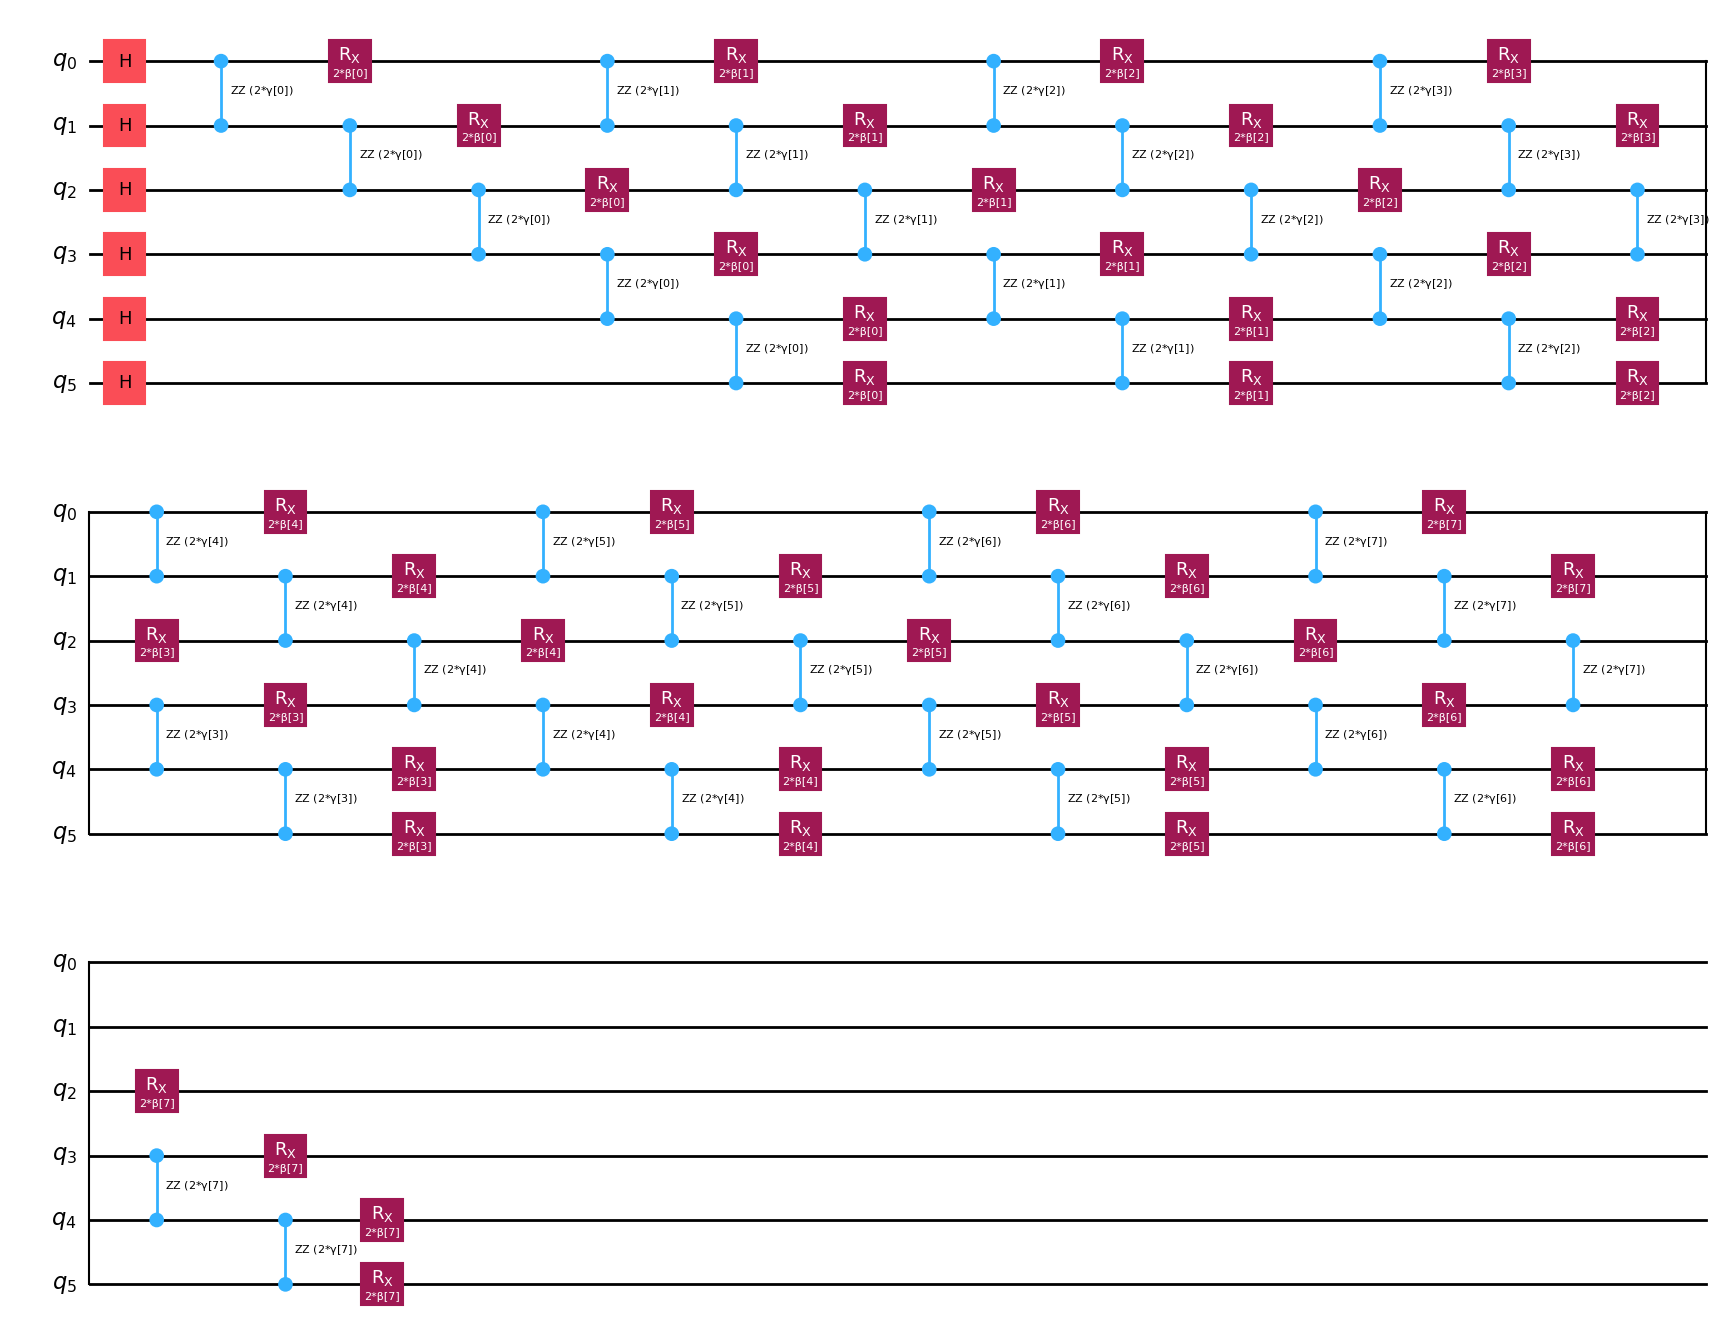

In [35]:
# Step 2. Optimize the circuit for the backend

backend = simulator_backend

pm = generate_preset_pass_manager(
    target=backend.target,
    optimization_level=3,
)

ansatz_6spin_isa = pm.run(ansatz_6spin)
ham_6spin_isa = ham_6spin.apply_layout(ansatz_6spin_isa.layout)

display(ansatz_6spin_isa.draw("mpl"))

In [39]:
# Step 3. Run VQE

vqe_result_6spin, param_history_6spin, energy_history_6spin = vqe(
    ansatz=ansatz_6spin_isa,
    ham=ham_6spin_isa,
    backend=None,
)

vqe_energy_6spin = float(vqe_result_6spin.fun)

print("VQE finished.")
print(f"VQE ground-state energy estimate: {vqe_energy_6spin:.10f}")
print("Optimal parameters:")
print(vqe_result_6spin.x)

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 1000   Least value of F = -5.925083068752095   Constraint violation = 0.0
The corresponding X is:
[-0.04568148  0.05309746  0.10566171  0.19902214  1.01691641  0.96933753
  0.89451577 -0.11072275  0.00184013  0.13543029  0.1948818   0.14670595
 -0.08781426 -0.54835866  0.18253393  0.0552411 ]
The constraint value is:
[-3.09591117 -3.19469011 -3.24725436 -3.3406148  -4.15850907 -4.11093018
 -4.03610842 -3.0308699  -3.14343278 -3.27702295 -3.33647445 -3.28829861
 -3.05377839 -2.59323399 -3.32412658 -3.19683375 -3.18727414 -3.08849519
 -3.03593094 -2.94257051 -2.12467624 -2.17225513 -2.24707688 -3.2523154
 -3.13975253 -3.00616236 -2.94671086 -2.9948867  -3.22940692 -3.68995132
 -2.95905872 -3.08635155]

VQE finished.
VQE ground-state energy estimate: -5.9250830688
Optimal parameters:
[-0.04568148  0.05309746  0.10566171  0.19902214  1.01691641  0.96933753
  0.89451577 -0.11072275

In [40]:
# Step 4. Exact diagonalization

ham_matrix = ham_6spin.to_matrix()

eigenvalues, eigenvectors = np.linalg.eigh(ham_matrix)
exact_ground_energy = float(np.real(eigenvalues[0]))

print(f"Exact ground-state energy: {exact_ground_energy:.10f}")
print(f"VQE energy:                 {vqe_energy_6spin:.10f}")
print(f"Absolute error:             {abs(vqe_energy_6spin - exact_ground_energy):.10e}")

Exact ground-state energy: -6.0776390824
VQE energy:                 -5.9250830688
Absolute error:             1.5255601365e-01


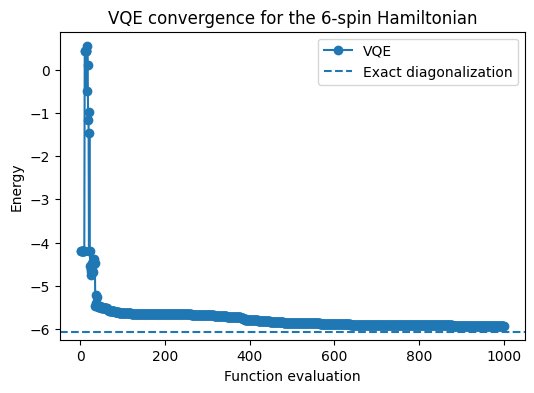

In [41]:
# Plot convergence

plt.figure(figsize=(6, 4))

plt.plot(
    range(1, len(energy_history_6spin) + 1),
    energy_history_6spin,
    marker="o",
    label="VQE",
)

plt.axhline(
    exact_ground_energy,
    linestyle="--",
    label="Exact diagonalization",
)

plt.xlabel("Function evaluation")
plt.ylabel("Energy")
plt.title("VQE convergence for the 6-spin Hamiltonian")
plt.legend()
plt.show()